<a href="https://colab.research.google.com/github/AlejoCNYT/Curso_CENDES/blob/main/Soluci%C3%B3n_CAPTCHAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Identificación de Captchas Usando Redes Convolucionales
_(M.Sc) Johan Sánchez Torres_

Hemos estudiado y comprendido los conceptos de redes convolucionales, sus principales arquitecturas y su aplicación en tareas de clasificación de imágenes. Ahora, es momento de aplicar estos conocimientos en una tarea particular: la identificación de Captchas. Para este problema, usamos la base de datos disponible en [Captcha](https://www.researchgate.net/publication/248380891_CAPTCHA_dataset).

## 1. Librerías Usadas

In [1]:
import numpy as np
%matplotlib inline
from keras.utils import plot_model
import matplotlib.pyplot as plt
import os
from keras import layers
from keras.models import Model
from keras.models import load_model
import cv2
import string
import tensorflow as tf
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
#from keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import ImageDataGenerator

## 2. Carga de Datos.
Se descarga la base de datos como un archivo `.zip`, el archivo quedará almacenado dentro de la sesión de Google Colab, no ocupa espacio en nuestro disco.

In [2]:
!wget --load-cookies /tmp/cookies.txt "https://docs.google.com/uc?export=download&confirm=$(wget --quiet --save-cookies /tmp/cookies.txt --keep-session-cookies --no-check-certificate 'https://docs.google.com/uc?export=download&id=1EcTWqMW8tLYQ32_MXg2m_xrWo1w0AqXf' -O- | sed -rn 's/.*confirm=([0-9A-Za-z_]+).*/\1\n/p')&id=1EcTWqMW8tLYQ32_MXg2m_xrWo1w0AqXf" -O "Data.zip" && rm -rf /tmp/cookies.txt

--2026-05-20 21:47:40--  https://docs.google.com/uc?export=download&confirm=&id=1EcTWqMW8tLYQ32_MXg2m_xrWo1w0AqXf
Resolving docs.google.com (docs.google.com)... 74.125.142.113, 74.125.142.138, 74.125.142.139, ...
Connecting to docs.google.com (docs.google.com)|74.125.142.113|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1EcTWqMW8tLYQ32_MXg2m_xrWo1w0AqXf&export=download [following]
--2026-05-20 21:47:40--  https://drive.usercontent.google.com/download?id=1EcTWqMW8tLYQ32_MXg2m_xrWo1w0AqXf&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 74.125.142.132, 2607:f8b0:400e:c1b::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|74.125.142.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10036086 (9.6M) [application/octet-stream]
Saving to: ‘Data.zip’

Data.zip            100%[===================>]   9.57M  --.-KB/s 

In [3]:
# Se descomprime el archivo zip para acceder a las imágenes.
!unzip Data.zip -d Data

Archive:  Data.zip
   creating: Data/captcha_dataset/
  inflating: Data/__MACOSX/._captcha_dataset  
  inflating: Data/captcha_dataset/.DS_Store  
  inflating: Data/__MACOSX/captcha_dataset/._.DS_Store  
  inflating: Data/captcha_dataset/ml_data_3188.csv  
  inflating: Data/__MACOSX/captcha_dataset/._ml_data_3188.csv  
   creating: Data/captcha_dataset/samples/
  inflating: Data/__MACOSX/captcha_dataset/._samples  
  inflating: Data/captcha_dataset/ml_test_3188.csv  
  inflating: Data/__MACOSX/captcha_dataset/._ml_test_3188.csv  
  inflating: Data/captcha_dataset/samples/p5g5m.png  
  inflating: Data/__MACOSX/captcha_dataset/samples/._p5g5m.png  
  inflating: Data/captcha_dataset/samples/e72cd.png  
  inflating: Data/__MACOSX/captcha_dataset/samples/._e72cd.png  
  inflating: Data/captcha_dataset/samples/pgmn2.png  
  inflating: Data/__MACOSX/captcha_dataset/samples/._pgmn2.png  
  inflating: Data/captcha_dataset/samples/6cm6m.png  
  inflating: Data/__MACOSX/captcha_dataset/samples/._

## 3. Preparación de los datos.
A continuación, se definen algunas funciones importantes para la carga y procesamiento de los datos.

In [4]:
# Se calcula la cantidad de imágenes en la base de datos
N = len(os.listdir("Data/captcha_dataset/samples"))
print(N)

1070


In [5]:
# Se define el tamaño de las imágenes requerido.
Ishape=(50,200,1) # Un canal debido a que son imágenes en escala de grises

In [6]:
# Número de posibles caracteres en las imágenes
character= string.ascii_lowercase + "0123456789" # todos los símbolos que puede
                                                 # contener un captcha, las letras
                                                 # del abecedario y los números
                                                 # [0,9]
# número de posibles caracteres
N_char = len(character)
N_char

36

En este caso, lo primero será realizar una codificación de las etiquetas usando formato onehot-encoding

In [7]:
# Número de posibles caracteres en las imágenes
characters = string.ascii_lowercase + "0123456789"  # Todos los símbolos que puede contener un captcha
N_char = len(characters)

# Función para realizar One-Hot Encoding
def one_hot_encode(label):
    one_hot_matrix = np.zeros((len(label), N_char))  # Crear una matriz de ceros
    for j, char in enumerate(label):
        index = characters.find(char)
        if index == -1:
            raise ValueError(f"El carácter '{char}' no está en el conjunto de caracteres permitidos.")
        one_hot_matrix[j, index] = 1  # Establecer 1 en la posición correspondiente
    return one_hot_matrix

# Función para la carga y proceso de las imágenes
def load_process(N=1070, Ishape=(50, 200, 1)): # Provide default values for N and Ishape
    X = np.zeros((N,) + Ishape)  # Arreglo que contiene las imágenes
    y = np.zeros((N, 5, N_char))  # Arreglo que contiene las etiquetas en formato One-Hot
    lab = []  # Se almacenan las etiquetas en formato de texto

    # Se cargan las imágenes de la base de datos
    file_dir = 'Data/captcha_dataset/samples'
    for i, ima in enumerate(os.listdir(file_dir)):
        # Se leen las imágenes en escala de grises
        img = cv2.imread(os.path.join(file_dir, ima), cv2.IMREAD_GRAYSCALE)
        label = ima[:-4]  # El nombre del archivo que corresponde con su etiqueta
        if len(label) < 6:
            lab.append(label)
            img = img / 255.0  # Se reescala la imagen
            img = np.reshape(img, Ishape[0:2])  # Se cambia el tamaño de las imágenes # reshape to (50, 200)
            img = np.expand_dims(img, axis=-1) # add an extra dimension to match the shape (50, 200, 1)


            # Codificación One-Hot de la etiqueta
            y[i, :, :] = one_hot_encode(label)

            # Almacena la imagen
            X[i, :] = img

    return X, y, lab

Ahora, se muestran algunas de las imágenes.

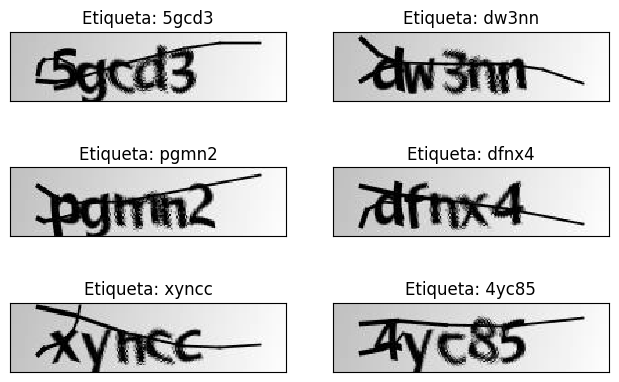

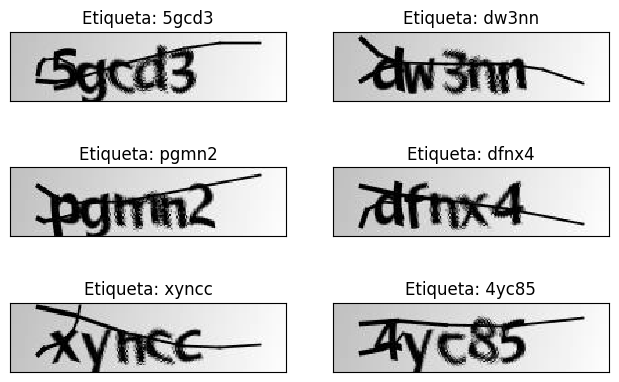

In [8]:
# Se cargan los datos y se muestran algunas imágenes
X, y, label = load_process()
fig = plt.figure()
for i in range(6):
  plt.subplot(3,2,i+1)
  plt.tight_layout()
  plt.imshow(X[i,:,:,0], cmap='gray', interpolation='none')
  plt.title("Etiqueta: {}".format(label[i]))
  plt.xticks([])
  plt.yticks([])
fig

Se definen los conjuntos para entrenamiento y para prueba de la siguiente manera.

In [9]:
# De las 1070 muestras, se usan 970 para el entrenamiento y 100 para la prueba.
x_train, y_train = X[:970,:,:,:], y[:970,:]
x_test, y_test = X[970:,:,:,:], y[970:,:]

In [10]:
c1 = x_train.shape[0]
c2  = x_train.shape[1]
c3 = x_train.shape[2]
c4 = x_train.shape[3]
input_shape = (c2, c3, c4)
print(input_shape) #tamaño de las imágenes
print(y_train[:,0])

print(y_test[:,0])

(50, 200, 1)
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 1. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


## 4. Red Convolucional.

### 4.1. Definición del modelo.

A continuación, se define una red convolucional, la cual utiliza un bucle para crear 5 salidas, una para cada carácter del CAPTCHA, donde
cada salida consiste en:
- *Dense(64, activation='relu'):* Capa densa con 64 neuronas y activación ReLU.
- *Dropout(0.5):* Capa de abandono que apaga el 50% de las neuronas durante el entrenamiento para prevenir el sobreajuste.
- *Dense(36, activation='softmax'):* Capa de salida con 36 neuronas (para 10 dígitos y 26 letras) y activación softmax, que produce probabilidades para cada clase.

In [11]:
def createmodel(input_shape):
    # Se define la entrada del modelo utilizando layers.Input,
    # que recibe la forma de la imagen como argumento.
    img = layers.Input(shape=input_shape)

    # Primera capa convolucional
    # Capa convolucional que aplica 16 filtros de tamaño 3x3. Usa la función de
    # activación ReLU y el padding 'same' para mantener el tamaño de la salida
    # igual al de la entrada.
    conv1 = layers.Conv2D(16, (3, 3), padding='same', activation='relu')(img)
    # Capa de max pooling que reduce la dimensionalidad de la salida de la capa convolucional.
    mp1 = layers.MaxPooling2D(padding='same')(conv1)

    # Segunda capa convolucional.
    conv2 = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(mp1)
    mp2 = layers.MaxPooling2D(padding='same')(conv2)

    # Tercera capa convolucional.
    conv3 = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(mp2)
    # Se agrega una capa de normalización por lotes (BatchNormalization) después de
    # la tercera capa convolucional, lo que ayuda a estabilizar y acelerar el entrenamiento.
    bn = layers.BatchNormalization()(conv3)
    mp3 = layers.MaxPooling2D(padding='same')(bn)

    # Se aplana la salida de la última capa de pooling para convertirla en un vector
    # unidimensional que se puede alimentar a las capas densas.
    flat = layers.Flatten()(mp3)

    outs = []  # Lista para almacenar las salidas

    # Crear 5 salidas, cada una para un dígito del CAPTCHA
    for _ in range(5):
        den = layers.Dense(64, activation='relu')(flat)
        drop = layers.Dropout(0.5)(den)
        sal = layers.Dense(36, activation='softmax')(drop)  # 36 clases alfanuméricas
        outs.append(sal)  # Añadir salida a la lista

    # Compilar el modelo
    model = Model(img, outs)
    # Se define la función de pérdida como categorical_crossentropy (debido al etiquetado onehot-encoding)
    #para cada una de las 5 salidas, ya que se trata de un problema de clasificación múltiple.
    loss = ['categorical_crossentropy'] * 5  # Usar la misma función de pérdida para todas las salidas
    model.compile(loss=loss, optimizer='adam', metrics=['accuracy']*5)

    return model

El código define un modelo de red neuronal convolucional diseñado para predecir los dígitos de un CAPTCHA que contiene cinco caracteres alfanuméricos. El modelo utiliza una arquitectura de red neuronal convolucional con varias capas convolucionales y de pooling, seguidas de capas densas y de salida. La función de pérdida utilizada es la entropía cruzada categórica y el optimizador es Adam. Este modelo devuelve una lista de 5 salidas, cada una correspondiente a un carácter del CAPTCHA.

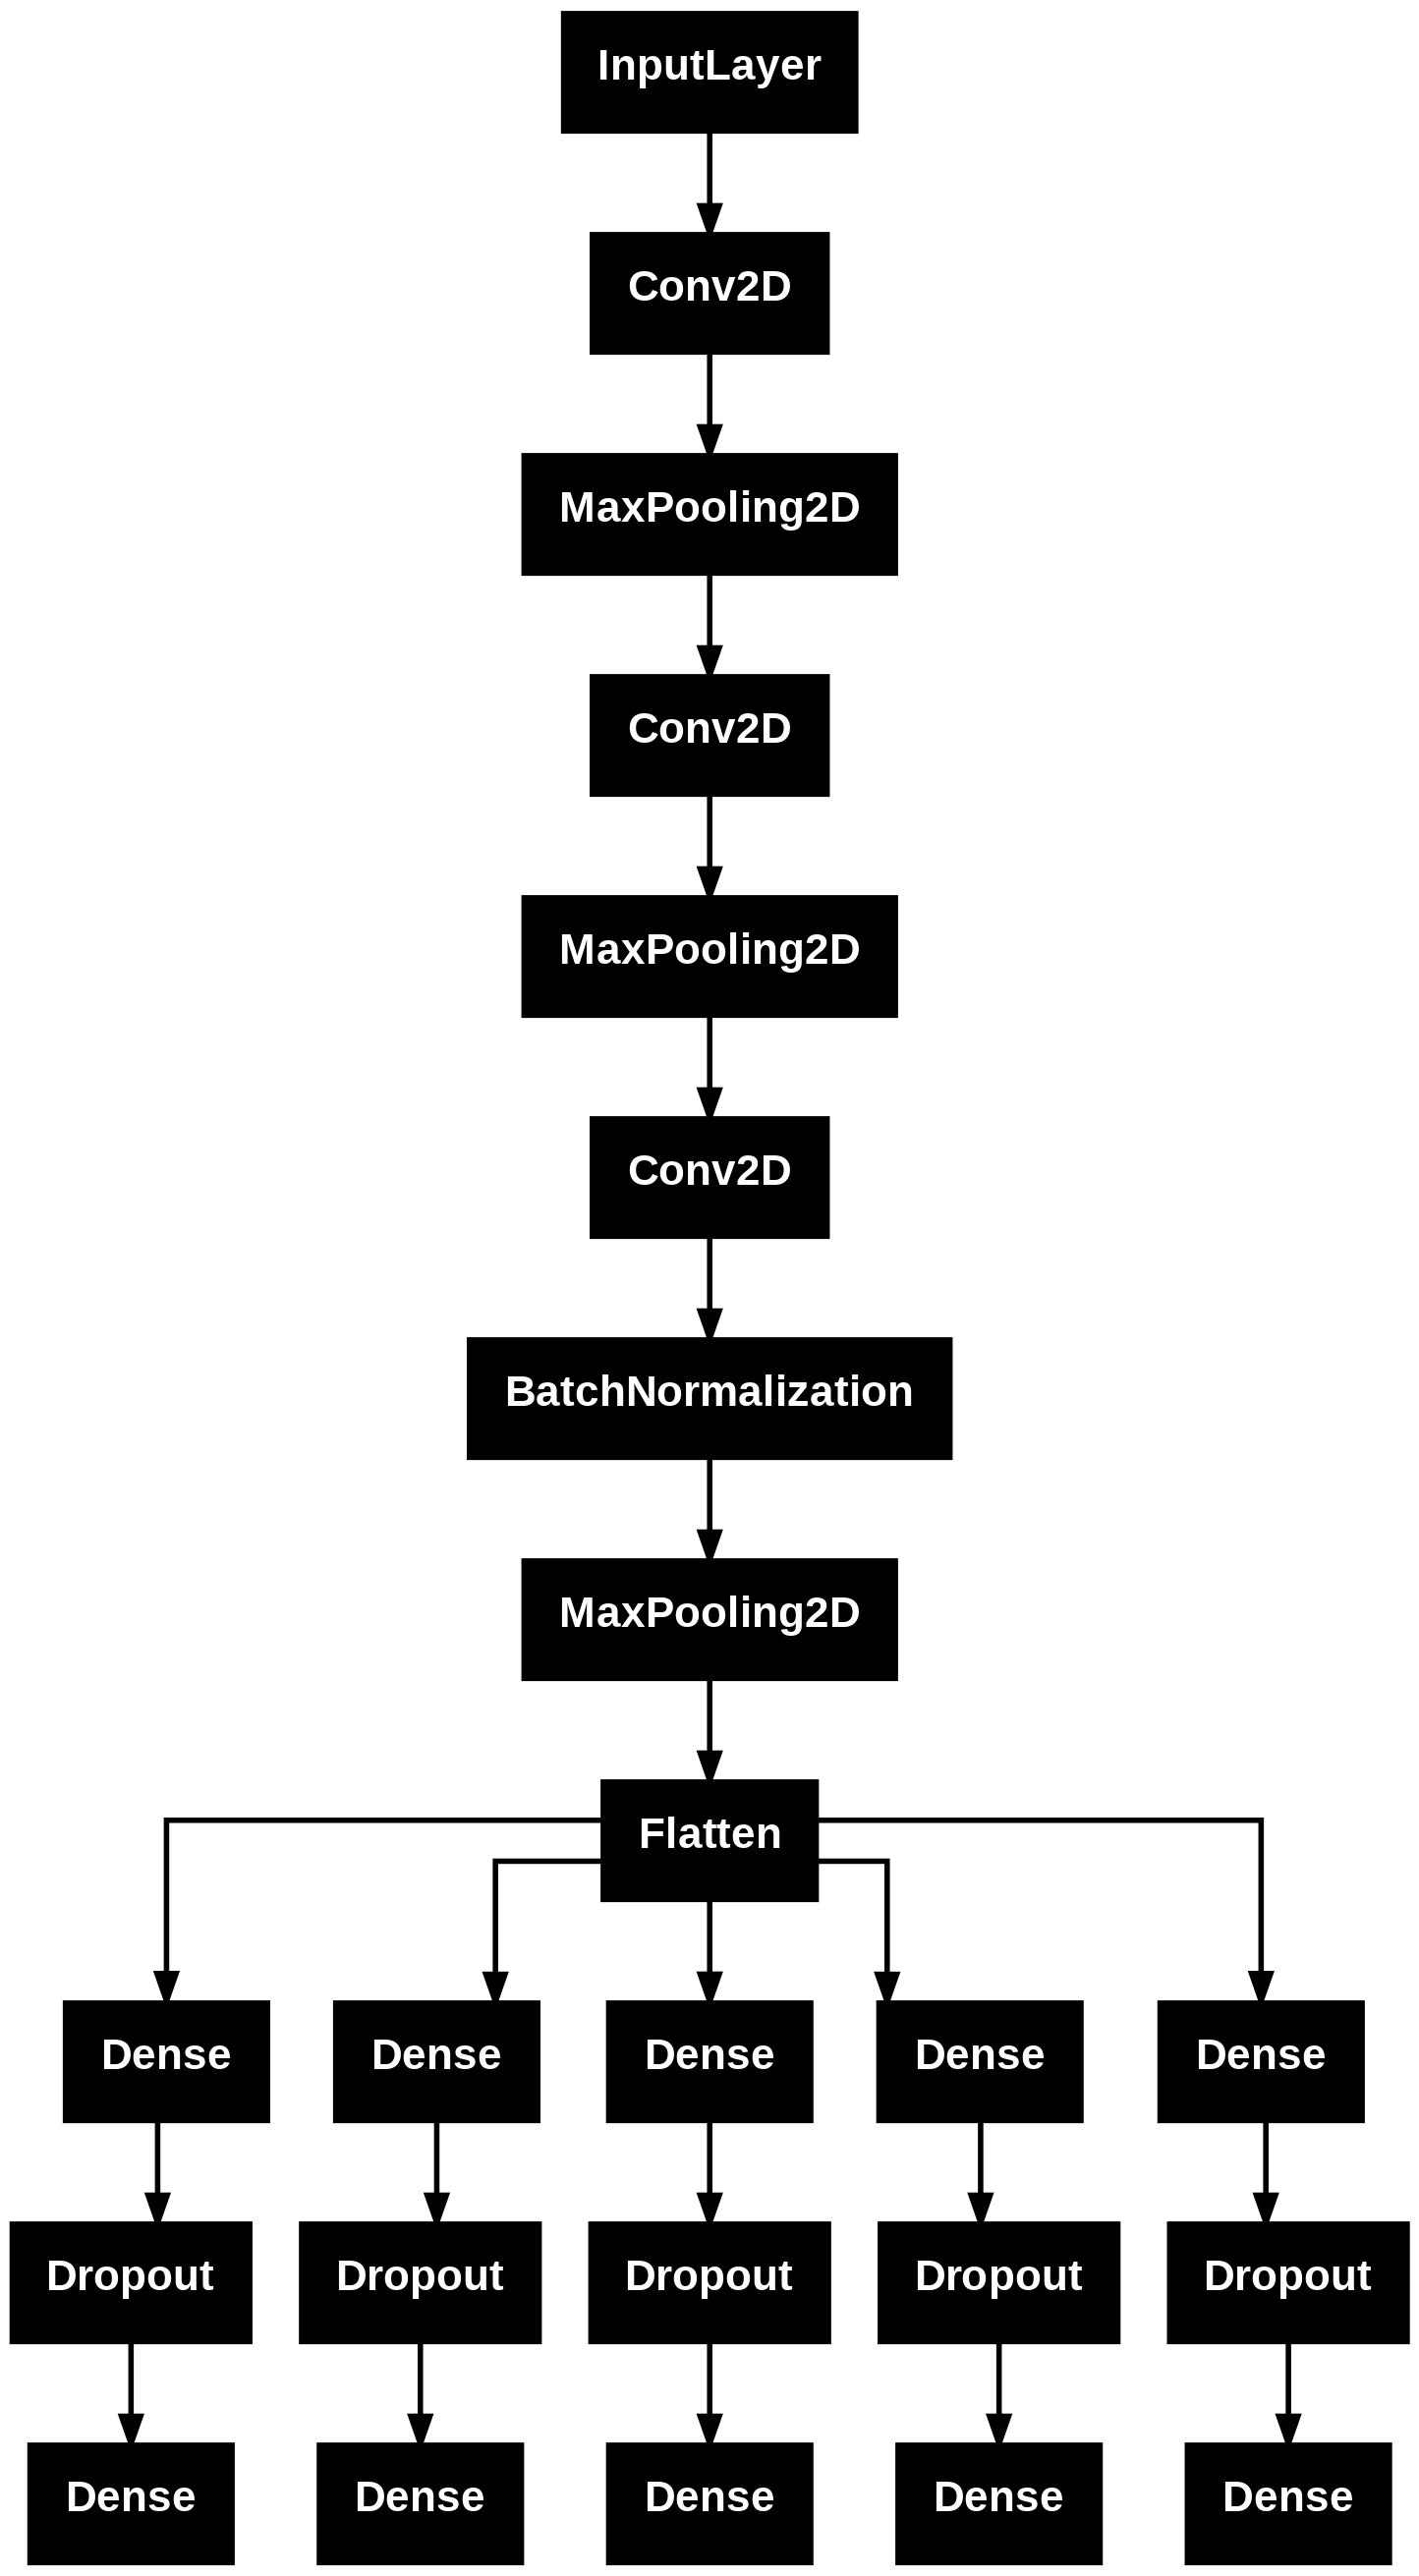

In [12]:
input_shape = (50, 200, 1)
model = createmodel(input_shape)
tf.keras.utils.plot_model(model)

### 4.2 Entrenamiento del modelo.
En este caso se va a entrenar un modelo de aprendizaje profundo para clasificar imágenes aplicando aumentos de datos. Primero, crea un modelo basado en el tamaño de las imágenes de entrada. Luego, aplica aumento de datos a las imágenes de entrenamiento y se reestructuran las etiquetas de entrenamiento y prueba. Finalmente, se entrena el modelo con los datos de entrenamiento y evaluación usando las imágenes aumentadas.

In [13]:
input_shape = x_train.shape[1:]
model = createmodel(input_shape)

# Definición del generador de datos (Data Augmentation)
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=False,
    fill_mode='nearest'
)

# Ajuste del generador a los datos de entrenamiento.
datagen.fit(x_train)

# Reestructuración de las etiquetas (y_train y y_test).
y_train_reshaped = [y_train[:, i] for i in range(5)]
y_test_reshaped = [y_test[:, i] for i in range(5)]

# Entrenamiento del modelo
history = model.fit(x_train, y_train_reshaped,
                    validation_data=(x_test, y_test_reshaped),
                    epochs=50,
                    batch_size=32)

Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 21s 302ms/step - dense_11_accuracy: 0.0536 - dense_11_loss: 3.5050 - dense_13_accuracy: 0.0557 - dense_13_loss: 3.6036 - dense_15_accuracy: 0.0495 - dense_15_loss: 3.5075 - dense_17_accuracy: 0.0577 - dense_17_loss: 3.5422 - dense_19_accuracy: 0.0577 - dense_19_loss: 3.5206 - loss: 17.6835 - val_dense_11_accuracy: 0.0600 - val_dense_11_loss: 3.5137 - val_dense_13_accuracy: 0.0800 - val_dense_13_loss: 3.5241 - val_dense_15_accuracy: 0.0500 - val_dense_15_loss: 3.5078 - val_dense_17_accuracy: 0.0700 - val_dense_17_loss: 3.4941 - val_dense_19_accuracy: 0.0400 - val_dense_19_loss: 3.5017 - val_loss: 17.5340
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - dense_11_accuracy: 0.0845 - dense_11_loss: 3.2313 - dense_13_accuracy: 0.0938 - dense_13_loss: 3.3184 - dense_15_accuracy: 0.0876 - dense_15_loss: 3.2562 - dense_17_accuracy: 0.0784 - dense_17_loss: 3.2257 - dense_19_accuracy: 0.0722 - dense_19_loss: 3.3289 - loss: 16.3550 - val_dense_11_accuracy:

### 4.2 Evaluación del modelo

In [14]:
# Realiza predicciones
predictions = model.predict(x_test)

# Convierte las predicciones de probabilidades a etiquetas
predicted_labels = [np.argmax(pred, axis=1) for pred in predictions]  # Lista de 5 arrays, uno para cada dígito

# Convierte las etiquetas verdaderas de one-hot a índices
true_labels = [np.argmax(y_test[:, i, :], axis=1) for i in range(5)]  # Lista de 5 arrays

# Inicializa una lista para almacenar las exactitudes
accuracies = []

# Evaluar cada dígito por separado
for i in range(5):
    accuracy = accuracy_score(true_labels[i], predicted_labels[i])
    accuracies.append(accuracy)  # Almacena la exactitud
    print(f"Exactitud para el caracter {i + 1}: {accuracy}")

# Calcula la exactitud promedio
average_accuracy = np.mean(accuracies)
print(f"Exactitud promedio: {average_accuracy}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 209ms/step
Exactitud para el caracter 1: 0.99
Exactitud para el caracter 2: 0.96
Exactitud para el caracter 3: 0.91
Exactitud para el caracter 4: 0.89
Exactitud para el caracter 5: 0.92
Exactitud promedio: 0.9339999999999999


In [15]:
  # Imprimir el informe de clasificación para obtener más detalles
  for i in range(5):
    accuracy = accuracy_score(true_labels[i], predicted_labels[i])
    print(classification_report(true_labels[i], predicted_labels[i]))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00         2
           2       0.80      1.00      0.89         4
           3       1.00      1.00      1.00         7
           4       1.00      0.83      0.91         6
           5       1.00      1.00      1.00         5
           6       1.00      1.00      1.00         3
          12       1.00      1.00      1.00         8
          13       1.00      1.00      1.00        14
          15       1.00      1.00      1.00         5
          22       1.00      1.00      1.00         3
          23       1.00      1.00      1.00         7
          24       1.00      1.00      1.00         3
          29       1.00      1.00      1.00         6
          30       1.00      1.00      1.00         8
          31       1.00      1.00      1.00         7
          32       1.00      1.00      1.00         6
          33       1.00      1.00      1.00         3
          34       1.00    

Al analizar el desempeño del modelo por clase, se observa una alta precisión en la clasificación de cada uno de los cinco caracteres, con valores de exactitud que oscilan entre 0.93 y 1.0. Estos resultados sugieren que el modelo ha aprendido a distinguir de manera efectiva las características distintivas de cada clase.  Estos resultados sugieren que el modelo ha aprendido a capturar las características distintivas de cada clase, es decir que el modelo está aprendiendo de manera efectiva y generalizando bien a nuevos datos.

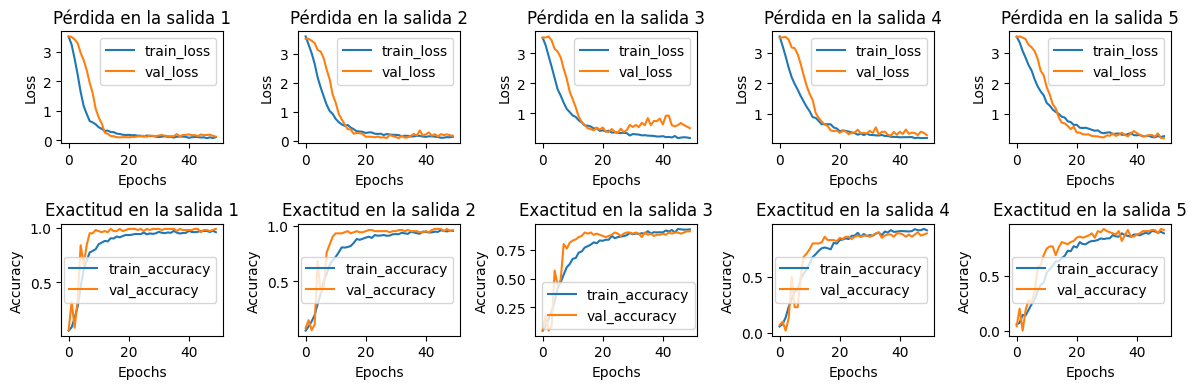

In [16]:
# Graficar la pérdida
plt.figure(figsize=(12, 4))

# Obtener las claves de pérdida y exactitud del historial
loss_keys = [key for key in history.history.keys() if 'loss' in key and 'val' not in key]
val_loss_keys = [key for key in history.history.keys() if 'loss' in key and 'val' in key]
acc_keys = [key for key in history.history.keys() if 'accuracy' in key and 'val' not in key]
val_acc_keys = [key for key in history.history.keys() if 'accuracy' in key and 'val' in key]

# Pérdida de entrenamiento y validación
for i in range(5):
    plt.subplot(2, 5, i + 1)
    plt.plot(history.history[loss_keys[i]], label='train_loss')  # Access using the correct key
    plt.plot(history.history[val_loss_keys[i]], label='val_loss') # Access using the correct key
    plt.title(f'Pérdida en la salida {i + 1}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

# Exactitud de entrenamiento y validación
for i in range(5):
    plt.subplot(2, 5, i + 6)
    plt.plot(history.history[acc_keys[i]], label='train_accuracy') # Access using the correct key
    plt.plot(history.history[val_acc_keys[i]], label='val_accuracy') # Access using the correct key
    plt.title(f'Exactitud en la salida {i + 1}')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

plt.tight_layout()
plt.show()

### 4.3. Algunas predicciones.

Un análisis visual de las predicciones realizadas por el modelo revela una notable concordancia entre los caracteres originales del captcha y las secuencias generadas por el modelo. Esto sugiere que el modelo ha aprendido a capturar las características distintivas de los caracteres y a generar predicciones precisas.

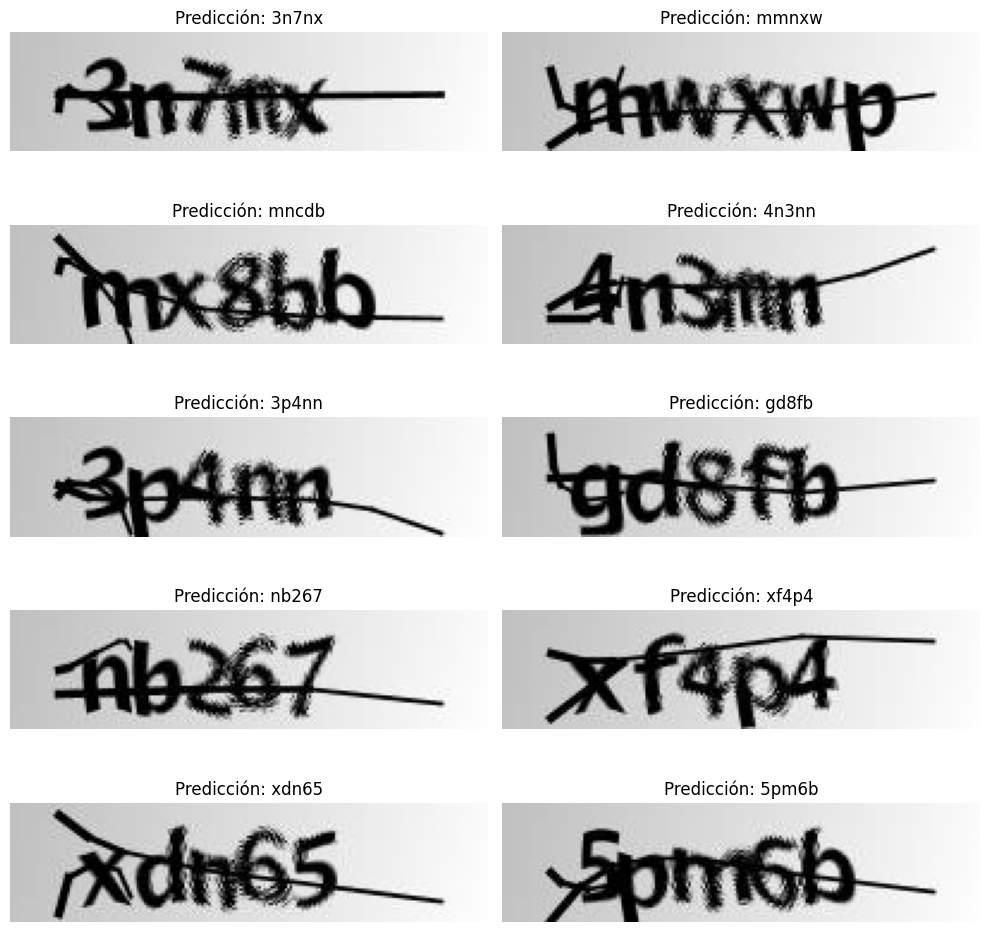

In [17]:
num_images = 10
fig, axs = plt.subplots(5, 2, figsize=(10, 10))  # Ajusta el tamaño de la figura según sea necesario

for i in range(num_images):
    ax = axs[i // 2, i % 2]
    ax.imshow(x_test[i, :, :, 0], cmap='gray')
    ax.set_title(f"Predicción: {''.join([characters[predicted_labels[j][i]] for j in range(5)])}")
    ax.axis('off')

plt.tight_layout()
plt.show()

## 5. Conclusiones.
- Las redes convolucionales multioutput ofrecen multiples ventajas, en este caso como nos enfrentabamos a un problema de clasificacín multiclase, estas redes fueron eficaces para solucionar el problema, mostranto una alta efectividad al momento de clasificar cada uno de los caracteres del captcha. Por otra parte, este tipo de redes son una poderosa herramienta en el aprendizaje profundo, especialmente en aplicaciones complejas donde se requieren múltiples salidas. Su capacidad para entrenar de manera conjunta, generalizar mejor y adaptarse a diferentes tareas las convierte en una opción eficaz para resolver diversos problemas de visión por computadora.

- Como se muestra los resultados de las predicciones realizadas por el modelo que se mostraron anteriormente, se evidencia de 10 salidas mostradas en 8 la predicción fue perfecta y en dos se mostró diferencias entre la etiqueta predicha y la imágen del captcha. Cabe resaltar que los errores mostrados se presentan en el cuarto caracter el cual es el que muestra una exactitud del 93% siendo la más baja con respecto a las demás salidas.
